In [ ]:

import sys
import subprocess

print("Python version   :", sys.version)
print("Python executable:", sys.executable)

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--upgrade", "pip"
])

core_packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "opencv-python",
    "pillow",
    "tqdm",
    "scikit-learn",
    "ipykernel"
]

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--upgrade", *core_packages
])

try:
    import tensorflow as _tf_test
    print("TensorFlow already working:", _tf_test.__version__)
except Exception as e:
    print("\nTensorFlow is missing/broken:", repr(e))
    print("Installing a clean TensorFlow copy...")

    subprocess.run([
        sys.executable, "-m", "pip", "uninstall", "-y",
        "tensorflow", "tensorflow-intel", "keras"
    ], check=False)

    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "--no-cache-dir", "--force-reinstall", "tensorflow"
    ])

print("\n✅ Package setup finished.")
print("IMPORTANT: Restart the VS Code/Jupyter kernel now, then run the next cell.")


Python version   : 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Python executable: c:\Users\emran\AppData\Local\Programs\Python\Python311\python.exe


TensorFlow already working: 2.21.0

✅ Package setup finished.
IMPORTANT: Restart the VS Code/Jupyter kernel now, then run the next cell.


In [2]:
from pathlib import Path
from collections import defaultdict
import hashlib, shutil
import sys

print("Running notebook with:")
print(sys.executable)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("\n✅ Imports successful")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("OpenCV:", cv2.__version__)
print("TensorFlow:", tf.__version__)


Running notebook with:
c:\Users\emran\AppData\Local\Programs\Python\Python311\python.exe


c:\Users\emran\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



✅ Imports successful
NumPy: 2.4.6
Pandas: 3.0.5
OpenCV: 5.0.0
TensorFlow: 2.21.0


In [3]:
DATASET_ROOT = Path("./DATASET")

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"DATASET folder not found: {DATASET_ROOT.resolve()}")

subfolders = [p.name for p in DATASET_ROOT.iterdir() if p.is_dir()]
print("Dataset:", DATASET_ROOT.resolve())
print("Folders:", subfolders)

if "Healthy" not in subfolders:
    raise FileNotFoundError("Healthy folder not found.")

if "LSD_Affected" in subfolders:
    LSD_CLASS = "LSD_Affected"
elif "LSD" in subfolders:
    LSD_CLASS = "LSD"
else:
    raise FileNotFoundError("LSD_Affected or LSD folder not found.")

CLASS_NAMES = ["Healthy", LSD_CLASS]
print("Classes:", CLASS_NAMES)


Dataset: E:\LSD_DETECTION_XAI_PROJECT\DATASET
Folders: ['Healthy', 'LSD_Affected']
Classes: ['Healthy', 'LSD_Affected']


In [4]:
SUPPORTED_EXTENSIONS = {".jpg",".jpeg",".png",".webp",".bmp",".avif"}

rows = []
for class_name in CLASS_NAMES:
    for p in (DATASET_ROOT/class_name).rglob("*"):
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS:
            rows.append({
                "Class": class_name,
                "File Name": p.name,
                "Extension": p.suffix.lower(),
                "Path": str(p.resolve())
            })

audit_df = pd.DataFrame(rows)
print("Total images:", len(audit_df))
display(audit_df.groupby("Class").size().rename("Image Count").to_frame())
display(pd.crosstab(audit_df["Class"], audit_df["Extension"]))


Total images: 649


,Image Count
Class,
Healthy,325
LSD_Affected,324


Extension,.avif,.jpeg,.jpg,.png,.webp
Class,,,,,
Healthy,14,1,302,0,8
LSD_Affected,5,14,260,4,41


In [5]:
bad_rows = []

for _, row in tqdm(audit_df.iterrows(), total=len(audit_df), desc="Checking images"):
    try:
        with Image.open(row["Path"]) as img:
            img.verify()
    except Exception as e:
        bad_rows.append({
            "Class": row["Class"],
            "File Name": row["File Name"],
            "Path": row["Path"],
            "Error": str(e)
        })

bad_df = pd.DataFrame(bad_rows)

if bad_df.empty:
    print("No corrupted/unreadable images found.")
else:
    print("Corrupted images:", len(bad_df))
    display(bad_df)


Checking images: 100%|██████████| 649/649 [00:07<00:00, 84.82it/s]

No corrupted/unreadable images found.


In [6]:
def decoded_pixel_hash(path):
    try:
        with Image.open(path) as img:
            img = img.convert("RGB")
            arr = np.asarray(img)
            h = hashlib.sha256()
            h.update(str(img.size).encode())
            h.update(arr.tobytes())
            return h.hexdigest()
    except Exception:
        return None

hash_groups = defaultdict(list)

for _, row in tqdm(audit_df.iterrows(), total=len(audit_df), desc="Finding duplicates"):
    p = Path(row["Path"])
    h = decoded_pixel_hash(p)
    if h:
        hash_groups[h].append(p)

duplicate_groups = [files for files in hash_groups.values() if len(files) > 1]

duplicate_rows = []
for group_no, files in enumerate(duplicate_groups, start=1):
    for p in files:
        duplicate_rows.append({
            "Duplicate Group": group_no,
            "Class": p.parent.name,
            "File Name": p.name,
            "Path": str(p)
        })

duplicate_df = pd.DataFrame(duplicate_rows)

if duplicate_df.empty:
    print("No exact duplicates found.")
else:
    print("Duplicate groups:", len(duplicate_groups))
    print("Files inside duplicate groups:", len(duplicate_df))
    display(duplicate_df)


Finding duplicates: 100%|██████████| 649/649 [01:17<00:00,  8.38it/s]

No exact duplicates found.


In [ ]:
def show_duplicate_group(group_number, max_images=8):
    if duplicate_df.empty:
        print("No duplicate groups.")
        return

    group = duplicate_df[duplicate_df["Duplicate Group"] == group_number]
    if group.empty:
        print("Group not found.")
        return

    n = min(len(group), max_images)
    fig, axes = plt.subplots(1, n, figsize=(4*n,4))
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, group.head(n).iterrows()):
        img = Image.open(row["Path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{row['Class']}\n{row['File Name']}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()





In [8]:
conflict_rows = []

for h, files in hash_groups.items():
    if len(files) < 2:
        continue
    classes = {p.parent.name for p in files}
    if len(classes) > 1:
        for p in files:
            conflict_rows.append({
                "Hash": h,
                "Class": p.parent.name,
                "File Name": p.name,
                "Path": str(p)
            })

conflict_df = pd.DataFrame(conflict_rows)

if conflict_df.empty:
    print("No exact duplicate appears in both classes.")
else:
    print("WARNING: Same image found in different classes.")
    print("These will NOT be auto-deleted.")
    display(conflict_df)


No exact duplicate appears in both classes.


In [9]:
files_to_delete = []

for files in duplicate_groups:
    classes = {p.parent.name for p in files}

    # Do not auto-delete cross-class conflicts
    if len(classes) > 1:
        continue

    keep_file = files[0]
    for p in files[1:]:
        files_to_delete.append({
            "Keep": str(keep_file),
            "Delete": str(p),
            "Class": p.parent.name,
            "File Name": p.name
        })

delete_plan_df = pd.DataFrame(files_to_delete)

if delete_plan_df.empty:
    print("No safe same-class duplicate copies need deletion.")
else:
    print("Proposed duplicate deletions:", len(delete_plan_df))
    display(delete_plan_df)

    confirmation = input(
        "Type YES to delete ONLY the duplicate copies shown above: "
    ).strip()

    if confirmation == "YES":
        deleted = 0
        for _, row in delete_plan_df.iterrows():
            p = Path(row["Delete"])
            if p.exists():
                p.unlink()
                deleted += 1
        print(f"Deleted {deleted} duplicate file(s).")
    else:
        print("Deletion cancelled. Nothing was deleted.")


No safe same-class duplicate copies need deletion.


In [10]:
rows = []

for class_name in CLASS_NAMES:
    for p in (DATASET_ROOT/class_name).rglob("*"):
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS:
            rows.append({
                "Class": class_name,
                "File Name": p.name,
                "Path": str(p.resolve())
            })

clean_audit_df = pd.DataFrame(rows)
print("Current total images:", len(clean_audit_df))
display(clean_audit_df.groupby("Class").size().rename("Image Count").to_frame())


Current total images: 649


,Image Count
Class,
Healthy,325
LSD_Affected,324


In [11]:
BLUR_THRESHOLD = 80.0
blur_rows = []

for _, row in tqdm(clean_audit_df.iterrows(), total=len(clean_audit_df), desc="Checking blur"):
    gray = cv2.imread(row["Path"], cv2.IMREAD_GRAYSCALE)
    if gray is None:
        continue
    score = cv2.Laplacian(gray, cv2.CV_64F).var()
    blur_rows.append({
        "Class": row["Class"],
        "File Name": row["File Name"],
        "Blur Score": float(score),
        "Potentially Blurry": score < BLUR_THRESHOLD,
        "Path": row["Path"]
    })

blur_df = pd.DataFrame(blur_rows).sort_values("Blur Score")
print("Potentially blurry images:", int(blur_df["Potentially Blurry"].sum()))
display(blur_df.head(20))


Checking blur: 100%|██████████| 649/649 [00:57<00:00, 11.32it/s]

Potentially blurry images: 64


,Class,File Name,Blur Score,Potentially Blurry,Path
350,LSD_Affected,129_lsd.jpg,7.834077,True,E:\LSD_DETECTION_XAI_PROJECT\DATASET\LSD_Affec...
486,LSD_Affected,89898767890.jpg,9.597572,True,E:\LSD_DETECTION_XAI_PROJECT\DATASET\LSD_Affec...
235,Healthy,pexels-khalilmazari-29373293.jpg,12.187981,True,E:\LSD_DETECTION_XAI_PROJECT\DATASET\Healthy\p...
278,Healthy,punto-fotografico-UxxTazW89bM-unsplash.jpg,14.681634,True,E:\LSD_DETECTION_XAI_PROJECT\DATASET\Healthy\p...
502,LSD_Affected,99_lsd.jpg,14.997638,True,E:\LSD_DETECTION_XAI_PROJECT\DATASET\LSD_Affec...
269,Healthy,pexels-ugur-hamzayev-1669656455-32544606.jpg,16.501633,True,E:\LSD_DETECTION_XAI_PROJECT\DATASET\Healthy\p...
254,Healthy,pexels-nandhukumar-16967612.jpg,17.697385,True,E:\LSD_DETECTION_XAI_PROJECT\DATASET\Healthy\p...
206,Healthy,pexels-drphotographer152-27661945.jpg,18.298900,True,E:\LSD_DETECTION_XAI_PROJECT\DATASET\Healthy\p...
119,Healthy,hty_50.jpg,20.459357,True,E:\LSD_DETECTION_XAI_PROJECT\DATASET\Healthy\h...
171,Healthy,larkin-hammond-iW7qU5OHoMU-unsplash.jpg,21.496727,True,E:\LSD_DETECTION_XAI_PROJECT\DATASET\Healthy\l...


In [12]:
paths = clean_audit_df["Path"].values
labels = clean_audit_df["Class"].values

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

split_df = pd.concat([
    pd.DataFrame({"Path":train_paths, "Class":train_labels, "Split":"train"}),
    pd.DataFrame({"Path":val_paths, "Class":val_labels, "Split":"val"}),
    pd.DataFrame({"Path":test_paths, "Class":test_labels, "Split":"test"})
], ignore_index=True)

display(pd.crosstab(split_df["Split"], split_df["Class"], margins=True))


Class,Healthy,LSD_Affected,All
Split,,,
test,49,49,98
train,227,227,454
val,49,48,97
All,325,324,649


In [13]:
SPLIT_DIR = Path("./DATASET_SPLIT")

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

for split_name in ["train","val","test"]:
    for class_name in CLASS_NAMES:
        (SPLIT_DIR/split_name/class_name).mkdir(parents=True, exist_ok=True)

for i, row in tqdm(split_df.iterrows(), total=len(split_df), desc="Creating split folders"):
    src = Path(row["Path"])
    dst = SPLIT_DIR/row["Split"]/row["Class"]/f"{row['Class']}_{i:04d}{src.suffix.lower()}"
    shutil.copy2(src, dst)

print("Created:", SPLIT_DIR.resolve())


Creating split folders: 100%|██████████| 649/649 [00:01<00:00, 462.84it/s]

Created: E:\LSD_DETECTION_XAI_PROJECT\DATASET_SPLIT


In [14]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR/"train",
    class_names=CLASS_NAMES,
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR/"val",
    class_names=CLASS_NAMES,
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR/"test",
    class_names=CLASS_NAMES,
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class order:", train_ds.class_names)


Found 416 files belonging to 2 classes.
Found 82 files belonging to 2 classes.
Found 83 files belonging to 2 classes.
Class order: ['Healthy', 'LSD_Affected']


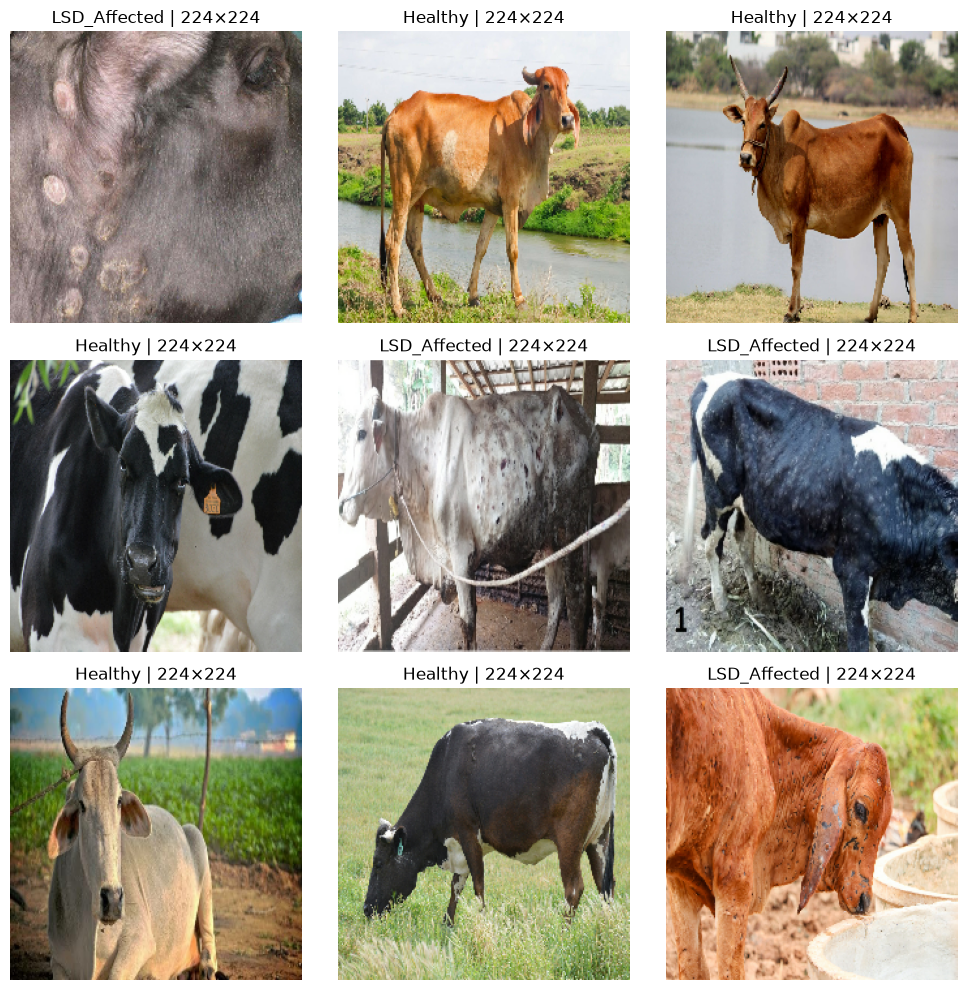

In [ ]:

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    n = min(9, images.shape[0])

    for i in range(n):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8).numpy())

        label_value = int(tf.reshape(labels[i], [-1])[0].numpy())
        class_name = CLASS_NAMES[label_value]
        plt.title(f"{class_name} | 224×224")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [16]:
normalization = layers.Rescaling(1./255)

for images, labels in train_ds.take(1):
    normalized = normalization(images)
    print("Before:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))
    print("After :", float(tf.reduce_min(normalized)), "to", float(tf.reduce_max(normalized)))


Before: 0.0 to 255.0
After : 0.0 to 1.0


In [17]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),
], name="data_augmentation")


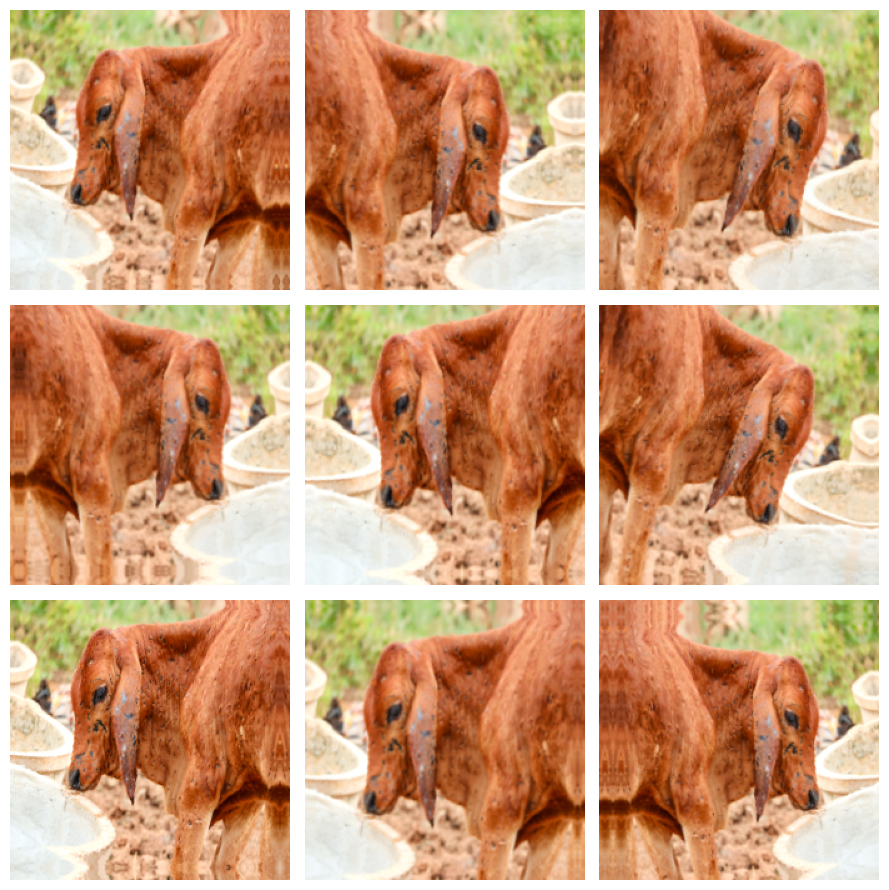

In [18]:
for images, labels in train_ds.take(1):
    image = images[0]
    plt.figure(figsize=(9,9))

    for i in range(9):
        augmented = data_augmentation(tf.expand_dims(image,0), training=True)
        ax = plt.subplot(3,3,i+1)
        plt.imshow(tf.cast(augmented[0], tf.uint8))
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [19]:
AUTOTUNE = tf.data.AUTOTUNE

def train_preprocess(images, labels):
    images = data_augmentation(images, training=True)
    images = normalization(images)
    return images, labels

def eval_preprocess(images, labels):
    return normalization(images), labels

train_ds_ready = train_ds.map(train_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_ready = val_ds.map(eval_preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds_ready = test_ds.map(eval_preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

print("Ready: train_ds_ready, val_ds_ready, test_ds_ready")


Ready: train_ds_ready, val_ds_ready, test_ds_ready


In [20]:
for images, labels in train_ds_ready.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 1)
Pixel range: 0.0 to 1.0
